In [ ]:
# prompt: df moi un code pour faire "df.describe" en important touts les packages nécessaire python, ensuite, il faut charger le fichier csv depuis drive google

from google.colab import drive
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt


# drive.mount('/content/drive')

# Remplacez 'chemin/vers/votre/fichier.csv' par le chemin réel de votre fichier sur Google Drive
file_path_1 = '/content/drive/MyDrive/ColabNotebooks/Projet_NLP/Phishing Email Dataset/Original/CEAS_08.csv' # Remplacez par le chemin de votre fichier
file_path_2 = '/content/drive/MyDrive/ColabNotebooks/Projet_NLP/Phishing Email Dataset/Original/Enron.csv' # Remplacez par le chemin de votre fichier
file_path_3 = '/content/drive/MyDrive/ColabNotebooks/Projet_NLP/Phishing Email Dataset/Original/Ling.csv' # Remplacez par le chemin de votre fichier
file_path_4 = '/content/drive/MyDrive/ColabNotebooks/Projet_NLP/Phishing Email Dataset/Original/Nazario.csv' # Remplacez par le chemin de votre fichier
file_path_5 = '/content/drive/MyDrive/ColabNotebooks/Projet_NLP/Phishing Email Dataset/Original/Nigerian_Fraud.csv' # Remplacez par le chemin de votre fichier
file_path_6 = '/content/drive/MyDrive/ColabNotebooks/Projet_NLP/Phishing Email Dataset/Original/SpamAssasin.csv' # Remplacez par le chemin de votre fichier
file_path_7 = '/content/drive/MyDrive/ColabNotebooks/Projet_NLP/Phishing Email Dataset/Original/phishing_email.csv' # Remplacez par le chemin de votre fichier
file_path_destination_merge='/content/drive/MyDrive/ColabNotebooks/Projet_NLP/Phishing Email Dataset/Original/dataset_merged.csv'
file_path_8 = file_path_destination_merge
file_path_9_save_model = '/content/drive/MyDrive/ColabNotebooks/Projet_NLP/dst/svm_tfidf_phishing.pkl'
file_path_10_dataset_2='/content/drive/MyDrive/ColabNotebooks/Projet_NLP/Phishing Email Dataset/Original/Phishing_Email_Dataset_2.csv'

try:
    df_ceas = pd.read_csv(file_path_1)
    df_enron = pd.read_csv(file_path_2)
    df_ling = pd.read_csv(file_path_3)
    df_nazario = pd.read_csv(file_path_4)
    df_nigerian_fraud = pd.read_csv(file_path_5)
    df_spam_assasin = pd.read_csv(file_path_6)
    df_phishing_email = pd.read_csv(file_path_7)
    df_merged = pd.read_csv(file_path_8,dtype={'urls': 'Int64'})

    #On précise dtype={'urls': 'Int64'} car urls contient des lignes de valeurs avec NaN du coup par défaut, pandas l'initialise par float, or ce n'est pas logique.

except FileNotFoundError:
    print(f"Erreur : Le fichier '{file_path_1}' n'a pas été trouvé. Veuillez vérifier le chemin.")
except Exception as e:
    print(f"Une erreur s'est produite lors du chargement ou de l'analyse du fichier : {e}")

regex_syntax_url_web=r"(https?://(?:www\.)?\S+|www\.\S+)"


# df.describe()

Pour la création du fichier csv concatener df_merged
Schéma cible
COLUMNS = ["sender", "receiver", "date", "subject", "body", "label", "urls"]

Dictionnaire des fichiers et leurs chemins
files = {
     "ceas_08.csv": file_path_1,
     "enron.csv": file_path_2,
     "ling.csv": file_path_3,
     "nazario.csv": file_path_4,
     "nigerian_fraud.csv": file_path_5,
     "spam_assasin.csv": file_path_6
}

Liste pour stocker tous les DataFrames
all_dfs = []

for name, path in files.items():
     df = pd.read_csv(path)
     # Ajouter les colonnes manquantes avec des valeurs vides
     for col in COLUMNS:
         if col not in df.columns:
             df[col] = None
     # Réordonner les colonnes selon le schéma cible
     df = df[COLUMNS]
     all_dfs.append(df)

Fusionner tous les DataFrames
 final_df = pd.concat(all_dfs, ignore_index=True)

Sauvegarde dans un nouveau fichier CSV
final_df.to_csv(file_path_destination_merge, index=False)
print(-f"Fichier fusionné sauvegardé sous file_path_destination_merge emplacement")


In [ ]:
# prompt: Oui, comment afficher les 30 premières lignes du dataset , vérifier s'il y a valeurs manquants pour chaque colonne

# Vérifier s'il y a des valeurs manquantes pour chaque colonne
print("Nombre de valeurs manquantes par colonne ceas:")
print(df_ceas.isnull().sum())
print('\n')

print("Nombre de valeurs manquantes par colonne enron:")
print(df_enron.isnull().sum())
print('\n')

print("Nombre de valeurs manquantes par colonne ling:")
print(df_ling.isnull().sum())
print('\n')

print("Nombre de valeurs manquantes par colonne nazario:")
print(df_nazario.isnull().sum())
print('\n')

print("Nombre de valeurs manquantes par colonne nigerian_fraud:")
print(df_nigerian_fraud.isnull().sum())
print('\n')

print("Nombre de valeurs manquantes par colonne spam_assasin:")
print(df_spam_assasin.isnull().sum())
print('\n')

print("Nombre de valeurs manquantes par colonne phishing_email:")
print(df_phishing_email.isnull().sum())
print('\n')

print("Nombre de valeurs manquantes par colonne merged:")
print(df_merged.isnull().sum())
print('\n')

doublons=df_merged.duplicated()
# Vérifie combien de lignes sont strictement dupliquées
nb_doublons = doublons.sum()
print(f"Nombre de doublons détectés sur df_merged: {nb_doublons}")

print('Nombre de ligne dataset: ', len(df_merged))


Nombre de valeurs manquantes par colonne ceas:
sender        0
receiver    462
date          0
subject      28
body          0
label         0
urls          0
dtype: int64


Nombre de valeurs manquantes par colonne enron:
subject    198
body         0
label        0
dtype: int64


Nombre de valeurs manquantes par colonne ling:
subject    62
body        0
label       0
dtype: int64


Nombre de valeurs manquantes par colonne nazario:
sender       0
receiver    96
date         1
subject      4
body         0
urls         0
label        0
dtype: int64


Nombre de valeurs manquantes par colonne nigerian_fraud:
sender       331
receiver    1324
date         482
subject       39
body           0
urls           0
label          0
dtype: int64


Nombre de valeurs manquantes par colonne spam_assasin:
sender        0
receiver    210
date          0
subject      16
body          1
label         0
urls          0
dtype: int64


Nombre de valeurs manquantes par colonne phishing_email:
text_combined 

In [ ]:
len(df_ceas)
len(df_enron)
len(df_ling)
len(df_nazario)
len(df_nigerian_fraud)
len(df_spam_assasin)
# len(df_phishing_email)

5809

In [ ]:

# Supprimer les limites d'affichage
pd.set_option('display.max_rows', 10)      # Affiche toutes les lignes
pd.set_option('display.max_columns', 10)   # Affiche toutes les colonnes
pd.set_option('display.width', None)         # Pas de coupure automatique
pd.set_option('display.max_colwidth', 10)  # Affiche tout le contenu des cellules

# Afficher les 5 premières lignes du dataset
print("Les 15 premières lignes du dataset ceas :")
df_ceas.head(-1)


Les 15 premières lignes du dataset ceas :


,sender,receiver,date,subject,body,label,urls
0,Young ...,user4@...,"Tue, 0...",Never ...,Buck u...,1,1
1,Mok <i...,user2....,"Tue, 0...",Befrie...,\nUpgr...,1,1
2,Daily ...,user2....,"Tue, 0...",CNN.co...,>+=+=+...,1,1
3,Michae...,SpamAs...,"Tue, 0...",Re: sv...,Would ...,0,1
4,Gretch...,user2....,"Tue, 0...",Specia...,\nWelc...,1,1
...,...,...,...,...,...,...,...
39148,Amee Z...,user2....,"Fri, 0...",Patien...,\n\nLa...,1,0
39149,CNN Al...,email1...,"Fri, 0...",CNN Al...,\n\nCN...,1,0
39150,CNN Al...,email1...,"Fri, 0...",CNN Al...,\n\nCN...,1,0
39151,Abhiji...,fxgmqw...,"Fri, 0...",Slides...,Hello ...,0,0


In [ ]:

from dateutil import parser
# Supprimer les limites d'affichage car les informations sont nombreuses et très important
# Donc il faut les afficher.

pd.set_option('display.max_rows', None)      # Affiche toutes les lignes
pd.set_option('display.max_columns', 10)   # Affiche toutes les colonnes
pd.set_option('display.width', None)         # Pas de coupure automatique
pd.set_option('display.max_colwidth', 500)  # Affiche tout le contenu des cellules

df_merged['text_raw'] = df_merged['subject'].fillna('') + ' ' + df_merged['body'].fillna('')

# print(df_merged.columns.to_list())

df_merged.head(55)

#df_merged.iloc[68927:68930]
#Start with 68927 no ulrs value

# # Définir le pattern regex pour détecter les URLs
url_pattern = re.compile(regex_syntax_url_web, re.IGNORECASE)

# # Filtrer les lignes où urls est NaN
mask_na = df_merged['urls'].isna()
# ça affiche ça
# 82429    False
# 82430    False
# 82431    False
# 82432    False

print("Avant : ", len(df_merged[mask_na]))

# affiche le nombre est valeur de urls qui est NaN
# df_merged[mask_na]

# Appliquer une détection de lien sur les text_raw correspondant OK sur test
def detect_url(text):
    if isinstance(text, str) and re.search(url_pattern, text):
        return 1
    else:
        return 0

df_merged.loc[mask_na, 'urls'] = df_merged.loc[mask_na, 'text_raw'].apply(detect_url)

# dt = parser.parse(df_merged.iloc[600]['date'])
# print(dt)
# print(type(dt))

# df_merged.head(55)


mask_na = df_merged['urls'].isna()
print("len après", len(df_merged[mask_na]))

df_merged.iloc[68927:68930]


Avant :  32626
len après 0


,sender,receiver,date,subject,body,label,urls,text_raw
68927,NaN,NaN,NaN,m . a . in scandinavian linguistics,"m . a . in scandinavian linguistics at the university of tromsoe 1995-1996 ( corrected version ) the linguistics section of the institute for language and literature at the university of tromsoe , norway , offers a one year course leading up to a master of arts degree , starting the fall of 1995 . the course is designed to prepare students for research in generative syntax and phonology with special attention to the scandinavian languages . the course is open to students from all countries w...",0,0,"m . a . in scandinavian linguistics m . a . in scandinavian linguistics at the university of tromsoe 1995-1996 ( corrected version ) the linguistics section of the institute for language and literature at the university of tromsoe , norway , offers a one year course leading up to a master of arts degree , starting the fall of 1995 . the course is designed to prepare students for research in generative syntax and phonology with special attention to the scandinavian languages . the course is o..."
68928,NaN,NaN,NaN,call for papers : linguistics session of the m / mla,"call for papers linguistics session - - midwest modern language association , st . louis , missouri , november 2 - 4 , 1995 topic : dialogue in fiction - - applications of theories / approaches from linguistic and cognitive sciences to dialogue in fiction . papers may explain how dialogue in fiction works ( with or without comparison to real conversation ) ; revise existing theories of language use , and perhaps offer new ones , based on analysis of dialogue in fiction ; or interpret texts t...",0,0,"call for papers : linguistics session of the m / mla call for papers linguistics session - - midwest modern language association , st . louis , missouri , november 2 - 4 , 1995 topic : dialogue in fiction - - applications of theories / approaches from linguistic and cognitive sciences to dialogue in fiction . papers may explain how dialogue in fiction works ( with or without comparison to real conversation ) ; revise existing theories of language use , and perhaps offer new ones , based on a..."
68929,NaN,NaN,NaN,foreign language in commercials,"content - length : 1937 greetings ! i ' m wondering if someone out there can identify the languages used in two recent ibm commercials . they have out a series of three ads with people in different countries talking about ibm equipment and services . one ad has two old gentlemen walking along what looks like the seine , speaking french . a second ad has two men sitting in what is apparently a middle eastern marketplace , and a third ad has nuns discussing ibm equipment on their way to mass ....",0,0,"foreign language in commercials content - length : 1937 greetings ! i ' m wondering if someone out there can identify the languages used in two recent ibm commercials . they have out a series of three ads with people in different countries talking about ibm equipment and services . one ad has two old gentlemen walking along what looks like the seine , speaking french . a second ad has two men sitting in what is apparently a middle eastern marketplace , and a third ad has nuns discussing ibm ..."


In [ ]:
print("Nombre de valeurs manquantes par colonne merged:")
print(df_merged.isnull().sum())
print('\n')


# Répartition de la variable cible
print("\nRépartition des label (phishing vs non-phishing) :")
print(df_merged['label'].value_counts(normalize=True))  # % de phishing
print("\nDétail brut :")
print(df_merged['label'].value_counts())  # nombre de cas


#Maintenant, ici, on a plus de valeurs urls NaN, du coup l'entrainement via les modèles peuvent s'effectuer sans problèmes.
print(nltk.__version__)


Nombre de valeurs manquantes par colonne merged:
sender      32957
receiver    34718
date        33109
subject       347
body            1
label           0
urls            0
text_raw        0
dtype: int64



Répartition des label (phishing vs non-phishing) :
label
1    0.519979
0    0.480021
Name: proportion, dtype: float64

Détail brut :
label
1    42891
0    39595
Name: count, dtype: int64
3.8.1


In [ ]:
#La version par défaut de nltk présente des bug du coup on downgrad
!pip install lxml
!pip uninstall -y nltk textblob
!pip install nltk==3.8.1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 40.7 MB/s eta 0:00:00
Found existing installation: nltk 3.9.1
Uninstalling nltk-3.9.1:
  Successfully uninstalled nltk-3.9.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 16.4 MB/s eta 0:00:00


In [ ]:
token_url="urltoken"
#Sert à changer les url pour que le modèle arrive bien à capter car avec un lien complet (https://domaine.com/sdsdssd/sds) le vocabulaire se met à
#Etre brouillé.

def split_camel_case(text):
    # Sépare les mots comme WelcomeFastShippingCustomerSupport → Welcome Fast Shipping Customer Support
    if text is None:
      return text
    else:
      return re.sub(r'([a-z])([A-Z])', r'\1 \2', text)

import html
def unescape_html(text):
    if text is None:
      return text
    else:
      return html.unescape(text)
      #ex : &amp; → &

from bs4 import BeautifulSoup
def remove_html_tags(text):
    if text is None:
      return text
    else:
      return BeautifulSoup(text, "lxml").get_text()
    #<div>text</div> → text
    #!pip install lxml (à exécuter dans Colab une fois)

def reduce_repeated_chars(text):
  if text is None:
    return text
  else:
    return re.sub(r'(.)\1{2,}', r'\1\1', text)
    #ex : "pleaaaase" → "pleaase"

# Remplacer tous les types de liens (http, https, www...) par <URL>
def replace_urls_web(text):
  if text is None:
    return text
  else:
    return re.sub(regex_syntax_url_web, token_url, text)

def remove_punctuation(text, token_url="urltoken", placeholder="URL_TOKEN"):
    # urltoken au lieu de "<url>"
    if not isinstance(text, str):
        return text

    return re.sub(r'[^\w\s]', '', text)



Test static des fonctions de pré-traitements.

text="\nWelcomeFastShippingCustomerSupport\nhttp://7iwfna.blu.livefilestore.com/y1pXdX3kwzhBa8xhXv8tdHbjHn7Tj4VT91YQg5lB5-_Hs9yuDwmU5wOteqBO-KnULiisB2QJJIug_bNfnrNH0YoSw/index.html\n\n\n"
print('Bonjour test',replace_urls_web(text))

text="\nUpgrade your sex and pleasures with these techniques http://www.brightmade.com\nOther wod\n\n"

text = unescape_html(text)
text = remove_html_tags(text)

text = split_camel_case(text)
On a des mots qui ont la forme syntaxique "SpecialPricesPharmMoreinfo" qui sont donc plusieurs mots (phrase) en un seul mot.

text = reduce_repeated_chars(text)
text = replace_urls_web(text)
text = remove_punctuation(text)
Supprimer la ponctuation (mais garder les chiffres)

text = text.lower()

print('text sorti ', text)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

tokens = word_tokenize(text)
Initialiser les outils
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

Supprimer les stopwords
tokens = [word for word in tokens if word not in stop_words]
print('tokens ',tokens)

Lemmatisation
tokens = [lemmatizer.lemmatize(word) for word in tokens]
print('tokens ',tokens)

Retourner le texte nettoyé
print (' '.join(tokens))

In [ ]:
# Code Python complet de prétraitement NLP
nltk.data.path.clear()
nltk.data.path.append('/content/drive/MyDrive/ColabNotebooks/Projet_NLP/src/nltk_data')

# # Télécharger les ressources nécessaires
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')
#Les téléchargement direct en ligne ne fonctionne pas, je l'ai télécharger manuellement et je l'ai mis dans mon workspace src/nltk_data
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print(nltk.__version__)

# Initialiser les outils
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


# Fonction de prétraitement du texte
def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    text = unescape_html(text)
    text = remove_html_tags(text)

    text = split_camel_case(text)
    # On a des mots qui ont la forme syntaxique "SpecialPricesPharmMoreinfo" qui sont donc plusieurs mots (phrase) en un seul mot.

    text = reduce_repeated_chars(text)
    text = replace_urls_web(text)
    text = remove_punctuation(text)
    # 3. Supprimer la ponctuation (mais garder les chiffres)

    text = text.lower()

    # 4. Tokenisation
    tokens = word_tokenize(text)

    # 5. Supprimer les stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # 6. Lemmatisation
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # 7. Retourner le texte nettoyé
    return ' '.join(tokens)

# # Appliquer le prétraitement NLP sur text_raw
df_merged['text_clean'] = df_merged['text_raw'].apply(preprocess_text)


3.8.1


In [ ]:
#Construction dataset déséquilibré (90 % non-phishing, label ==0 / 10 % phishing, label ==1)
# Sur le dataset merged, après calcul il faut 4399 de label == 1 et 39595 de label == 0 pour
# (90 % non-phishing, label ==0 / 10 % phishing, label ==1)
# A noter qu'en prend celle ou on a déjà fait le text_clean après pré-traitement.

# Séparer les lignes où label == 1 et label == 0
label_1_df = df_merged[df_merged['label'] == 1]
# label_1_df.head()
label_0_df = df_merged[df_merged['label'] == 0]
# Répartition de la variable cible

print("\nDétail brut label_1_df:")
print(label_1_df['label'].value_counts())  # nombre de cas
print("\nDétail brut label_0_df:")
print(label_0_df['label'].value_counts())  # nombre de cas

# # Garder seulement 4399 lignes de label == 1
label_1_df_limited = label_1_df.sample(n=4399, random_state=42)  # random_state pour la reproductibilité
print("label_1_df_limited : ",label_1_df_limited['label'].value_counts())  # nombre de cas

# # Recombiner les deux DataFrames
df_result = pd.concat([label_0_df, label_1_df_limited], ignore_index=True)

# # Optionnel : réorganiser les lignes (mélanger)
df_result = df_result.sample(frac=1, random_state=42).reset_index(drop=True)

# Répartition de la variable cible sur le nouveau dataset df_result
print("\nRépartition des label (phishing vs non-phishing) sur df_result:")
print(df_result['label'].value_counts(normalize=True))  # % de phishing
print("\nDétail brut df_result:")
print(df_result['label'].value_counts())  # nombre de cas





Détail brut label_1_df:
label
1    42891
Name: count, dtype: int64

Détail brut label_0_df:
label
0    39595
Name: count, dtype: int64
label_1_df_limited :  label
1    4399
Name: count, dtype: int64

Répartition des label (phishing vs non-phishing) sur df_result:
label
0    0.900009
1    0.099991
Name: proportion, dtype: float64

Détail brut df_result:
label
0    39595
1     4399
Name: count, dtype: int64


In [ ]:
# # Afficher les premières lignes pour vérification
df_merged.head()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack
#Etape Transformer le texte nettoyé (colonne text_clean) en vecteurs numériques
#exploitables par les modèles de Machine Learning.


# 1. Vectorisation TF-IDF
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(df_merged['text_clean'])

# 2. Ajout de la colonne urls comme variable additionnelle
X_urls = df_merged[['urls']].values  # numpy array 2D
X_combined = hstack([X_text, X_urls])  # combinaison sparse matrix + dense

# 3. Définir y
y = df_merged['label'].values

# 4. Séparer en jeu d'entraînement et test
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)



Afficher les dimensions les plus élevées du TF-IDF

Récupérer les noms des termes (colonnes du TF-IDF)
feature_names = tfidf.get_feature_names_out()

Moyenne TF-IDF par mot sur tout le corpus
mean_tfidf = X_text.mean(axis=0).A1  # .A1 pour transformer en tableau plat

Trier les indices des termes par poids décroissant
top_indices = np.argsort(mean_tfidf)[::-1]

Afficher les 20 mots les plus "importants"
top_terms = [(feature_names[i], mean_tfidf[i]) for i in top_indices[:20]]

Affichage lisible
print("Top 20 termes selon le poids moyen TF-IDF :\n")
for term, score in top_terms:
     print(f"{term:<20} → {score:.4f}")
print(X_combined)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, f1_score

# # 1. Régression Logistique
# logreg = LogisticRegression(max_iter=1000, C=1.0, solver='liblinear', random_state=42)
# logreg.fit(X_train, y_train)

# # On a l'erreur ici car sur l'initialisation du feature "urls", il existe des valeurs vides NaN0.
# # Solution pour ça, crée un algorithme, si dans text_raw on voit présence d'un lien(avec regex), on met directement à True
# # toutes les valeurs de urls correspondants.
# # C'est déjà régler avant

# y_pred_logreg = logreg.predict(X_test)

# # 2. Random Forest
# rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
# rf.fit(X_train, y_train)
# y_pred_rf = rf.predict(X_test)

# 3. SVM Linéaire
svm = LinearSVC(C=1.0, max_iter=1000, random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

# Évaluation
results = {
    # "Logistic Regression": {
    #     "Accuracy": accuracy_score(y_test, y_pred_logreg),
    #     "F1-score": f1_score(y_test, y_pred_logreg),
    #     "Report": classification_report(y_test, y_pred_logreg, output_dict=True)
    # },
    # "Random Forest": {
    #     "Accuracy": accuracy_score(y_test, y_pred_rf),
    #     "F1-score": f1_score(y_test, y_pred_rf),
    #     "Report": classification_report(y_test, y_pred_rf, output_dict=True)
    # },
    "SVM": {
        "Accuracy": accuracy_score(y_test, y_pred_svm),
        "F1-score": f1_score(y_test, y_pred_svm),
        "Report": classification_report(y_test, y_pred_svm, output_dict=True)
    }
}

# Convertir en DataFrame résumé
summary_df = pd.DataFrame({
    model: {
        "Accuracy": metrics["Accuracy"],
        "F1-score": metrics["F1-score"]
    }
    for model, metrics in results.items()
}).T.round(4)

In [ ]:
summary_df

,Accuracy,F1-score
SVM,0.9895,0.9899


[[7786  111]
 [  63 8538]]


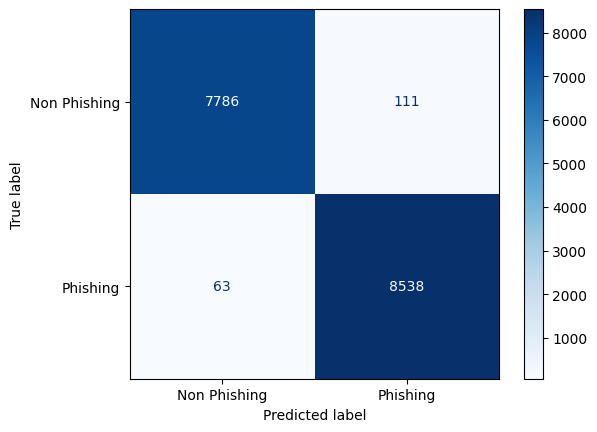

In [ ]:
# print('y_pred_svm', y_pred_svm)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_svm)
print(cm)

# [[ TN  FP ]
#  [ FN  TP ]]

# FP False Positive
# TP True Positive
# TN True Negative
# FN False Negative

ConfusionMatrixDisplay.from_predictions(
    y_test,          # ✅ valeurs vraies = ground truth
    y_pred_svm,      # ✅ prédictions du modèle
    display_labels=["Non Phishing", "Phishing"],
    cmap="Blues"
)

# Résumé des performances
# Avec cette répartition des label (phishing vs non-phishing) :
  # label
  # 1    0.519979
  # 0    0.480021

# On a les métriques suivantes:

# Métrique	              Valeur approximative.
# Accuracy	              (7786 + 8538) / total = 98.95 %
# Faux positifs	          111 cas sur +8400 non-phishing → très peu
# Faux négatifs	          63 phishing manqués sur +8600 → faible aussi
# Rappel (Recall)	        TP / (TP + FN) = 8538 / (8538 + 63) ≈ 99.27 %
# Précision (Precision)	  TP / (TP + FP) = 8538 / (8538 + 111) ≈ 98.72 %


In [ ]:
# On va tester sur un autre cas, où les labes sont déséquilibrés pour voir la performance du modèle SVM Linéaire
# On va simuler une situation réelle où :
  #     La majorité des emails sont légitimes (90 %),
  #     Une minorité sont phishing (10 %),
  #     Et tester le modèle dans ces conditions pour voir comment il réagit à un déséquilibre de classes

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Répartition de la variable cible sur le nouveau dataset df_result
print("\nRépartition des label (phishing vs non-phishing) sur df_result:")
print(df_result['label'].value_counts(normalize=True))  # % de phishing
print("\nDétail brut df_result:")
print(df_result['label'].value_counts())  # nombre de cas

# Supposons que 'tfidf' a déjà été entraîné avec .fit()
X_test_text = tfidf.transform(df_result['text_clean'])

# Ajouter la colonne urls comme feature
X_test_urls = df_result[['urls']].values

# Combinaison des features
X_test_final = hstack([X_test_text, X_test_urls])
y_test_final = df_result['label'].values

# Utiliser le modèle SVM déjà entraîné
y_pred_imbalance = svm.predict(X_test_final)
# Avec svm la variable du modèle d'avant.

print("Rapport de classification (déséquilibré) :")
print(classification_report(y_test_final, y_pred_imbalance, target_names=["Non Phishing", "Phishing"]))

print("\nMatrice de confusion :")
cm = confusion_matrix(y_test_final, y_pred_imbalance)
print(cm)

# Affichage graphique
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non Phishing", "Phishing"])
disp.plot(cmap="Blues")
plt.title("Matrice de Confusion - SVM (Test déséquilibré)")
plt.grid(False)
plt.show()


# | Classe           | Précision | Rappel | F1-score | Support |
# | ---------------- | --------- | ------ | -------- | ------- |
# | **Non phishing** | 1.00      | 1.00   | 1.00     | 39 595  |
# | **Phishing**     | 0.97      | 1.00   | 0.99     | 4 399   |

# Rappel pour phishing = 1.00 → aucun email de phishing n'a été manqué ❗️

# Précision phishing = 0.97 → seuls 3 % des prédictions "phishing" étaient des faux positifs.

# Accuracy globale = 1.00 sur 43 994 mails ➜ Excellent.


In [ ]:
# Pourquoi ton modèle n'est pas à 100 % parfait ?
# Il y a plusieurs raisons naturelles à cela :
# Limite	Explication
# 🔹 Modèle simple (SVM)	Il apprend des statistiques sur des mots, mais pas de sémantique ni de logique.
# 🔹 Données imparfaites	Il y aura toujours des mails ambigus, difficiles même pour un humain à classer.
# 🔹 Sur-apprentissage partiel	Certains mots comme “cheap” ou “flash” peuvent être appris comme suspects même dans des cas légitimes.
# 🔹 Pas de vision multimodale	Le modèle ne voit que le texte : pas d'images, pas de méta-données (ex: DNS, historique d’envoi, réputation).


# Peut-on avoir un modèle 100 % parfait ?
# 🎯 En théorie :

# Non. Aucune IA ne peut atteindre 100 % de rappel ET 100 % de précision en toutes circonstances.
# 🧠 Pourquoi ?

#     Ambiguïté naturelle du langage :
#     Certains emails sont indiscernables sans informations supplémentaires (IP, réputation du domaine…).

#     Évolution constante des attaques :
#     Les attaquants changent sans cesse de technique → les données d’entraînement deviennent obsolètes.

#     Erreurs humaines :
#     Même les humains ne sont pas à 100 % en détection de phishing.

In [ ]:
# Sauvegarder le modèle

import joblib
joblib.dump((svm, tfidf), file_path_9_save_model)
print('Save model svm, tfidf successful')

Save model svm, tfidf successful


In [ ]:
# Analysons maintenant, quels sont les informations(ligne,  122) qui ont été classé FP

# Supposons que df_result, X_test_text, y_test_final, y_pred_imbalance, tfidf existent déjà

# Étape 1 : Trouver les indices des faux positifs (FP)
# fp_indices = np.where((y_test_final == 0) & (y_pred_imbalance == 1))[0]

# # Étape 2 : Extraire les emails faux positifs depuis df_result
# false_positives_df = df_result.iloc[fp_indices]
# # len(false_positives_df)
# # ça affiche bien 122

# # Étape 3 : Afficher les 10 premiers faux positifs pour revue humaine
# false_positives_preview = false_positives_df[['subject', 'body', 'text_clean']].head(10)

# # false_positives_df



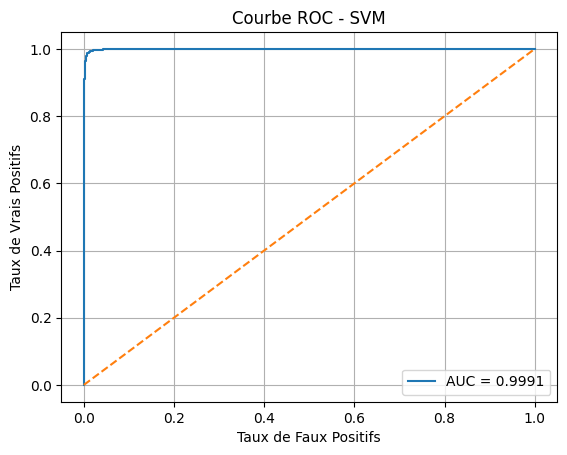

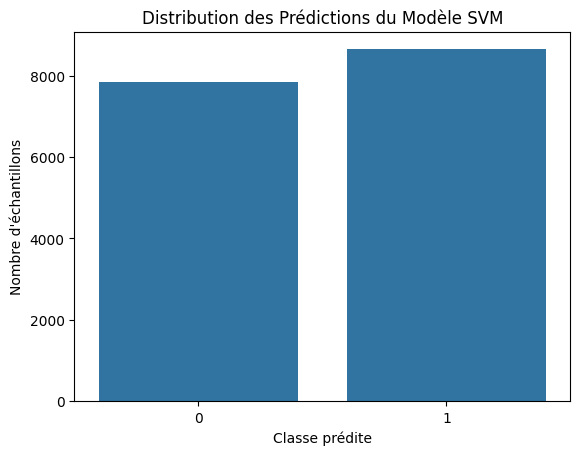

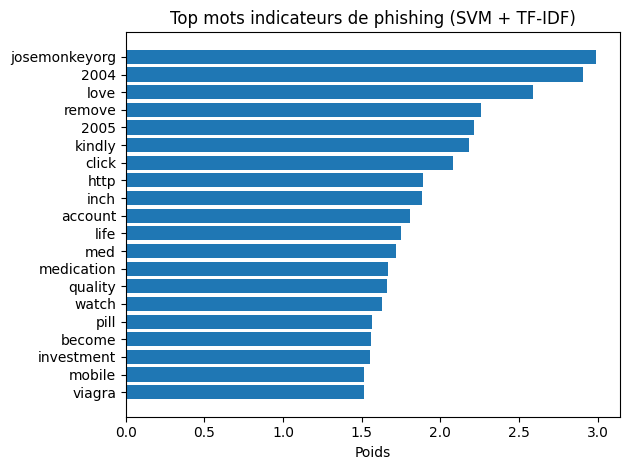

In [ ]:
# Graphiques d'illustration de performances
from sklearn.metrics import roc_curve, roc_auc_score
# Courbe ROC + AUC
# Attention : LinearSVC n’a pas predict_proba → utilise decision_function
y_scores = svm.decision_function(X_test)
fpr, tpr, _ = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)

plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("Taux de Faux Positifs")
plt.ylabel("Taux de Vrais Positifs")
plt.title("Courbe ROC - SVM")
plt.legend()
plt.grid()
plt.show()

# Histogramme des prédictions (classes 0 vs 1)

import seaborn as sns

sns.countplot(x=y_pred_svm)
plt.title("Distribution des Prédictions du Modèle SVM")
plt.xlabel("Classe prédite")
plt.ylabel("Nombre d'échantillons")
plt.show()

# Importance des mots (TF-IDF)

feature_names = tfidf.get_feature_names_out()
svm_coef = svm.coef_.flatten()
top_phishing_indices = np.argsort(svm_coef)[-20:]
top_words = [feature_names[i] for i in top_phishing_indices]
top_weights = svm_coef[top_phishing_indices]

plt.barh(top_words, top_weights)
plt.title("Top mots indicateurs de phishing (SVM + TF-IDF)")
plt.xlabel("Poids")
plt.tight_layout()
plt.show()



In [ ]:
# Tester un nouveau dataset Phishing_Email_Dataset_2.csv pour savoir l'éfficacité du modèle mais avant ça,
# On va prétraiter le dataset avec comme extrait :
# "
# "Email Text"    "Email Type"
# blablabla       "Safe Email" or "Phishing Email"
# "
# Pour ressembler à notre pramètres d'entrés de dataset
df_dataset_2 = pd.read_csv(file_path_10_dataset_2)
df_dataset_2 = df_dataset_2.drop(df_dataset_2.index[-1])
#Supprimer la dernière ligne car il y a un champ empty

# 1) Supprimer toute colonne « Unnamed » (qu’elle se nomme exactement 'Unnamed: 0'
#    ou qu’un autre indice similaire ait été créé lors du read_csv)
df_dataset_2 = df_dataset_2.drop(columns=[c for c in df_dataset_2.columns if c.lower().startswith('unnamed')])
# df_dataset_2.head()
# Ok

# 2) Renommer les colonnes
df_dataset_2 = df_dataset_2.rename(columns={
    "Email Text": "body",
    "Email Type": "label"
})
# df_dataset_2.head()
# Ok

# 3) Convertir la colonne label en indicateur booléen / entier
#    Phishing Email → 1 ; Safe Email → 0
df_dataset_2["label"] = df_dataset_2["label"].map({
    "Phishing Email": True,
    "Safe Email": False
}).astype("Int64")     # entier nullable propre
# df_dataset_2.head()
# Ok

# 4) Ajouter les colonnes vides demandées
for new_col in ["sender", "receiver", "date", "subject", "urls"]:
    df_dataset_2[new_col] = pd.NA    # pd.NA est le NaN générique pour tout type

# df_dataset_2.head()
# Ok

# Creer la colonne text_raw avec body+subject
df_dataset_2['text_raw'] = df_dataset_2['subject'].fillna('') + ' ' + df_dataset_2['body'].fillna('')
# df_dataset_2.head()
# Ok

# Remplir la colonne urls avec l'algorithme utilisé sur les codes ci-dessus

# # Filtrer les lignes où urls est NaN
mask_na = df_dataset_2['urls'].isna()

print("Avant : ", len(df_dataset_2[mask_na]))

# # affiche le nombre est valeur de urls qui est NaN
# # df_dataset_2[mask_na]

# df_dataset_2.head()
# Ok
df_dataset_2.loc[mask_na, 'urls'] = df_dataset_2.loc[mask_na, 'text_raw'].apply(detect_url)
# df_dataset_2.head()
# Ok

# # Appliquer le prétraitement NLP sur text_raw sur le nouveau dataset df_dataset_2
df_dataset_2['text_clean'] = df_dataset_2['text_raw'].apply(preprocess_text)


# df_dataset_2.head()
mask_na = df_merged['urls'].isna()
print("len après", len(df_merged[mask_na]))

# Répartition de la variable cible sur le nouveau dataset df_dataset_2
print("\nRépartition des label (phishing vs non-phishing) sur df_dataset_2:")
print(df_dataset_2['label'].value_counts(normalize=True))  # % de phishing
print("\nDétail brut df_dataset_2:")
print(df_dataset_2['label'].value_counts())  # nombre de cas

# Assurer que la colonne est bien booléenne car il se peut qu'on a une erreur
df_dataset_2['urls'] = df_dataset_2['urls'].astype(bool)

# Maintenant, on peut passer le test de prédiction avec le modèle.

# Supposons que 'tfidf' a déjà été entraîné avec .fit()
X_test_text = tfidf.transform(df_dataset_2['text_clean'])

# Ajouter la colonne urls comme feature
X_test_urls = df_dataset_2[['urls']].values

# Combinaison des features
X_test_final = hstack([X_test_text, X_test_urls])
y_test_final = df_dataset_2['label'].values

# Utiliser le modèle SVM déjà entraîné
y_pred_imbalance = svm.predict(X_test_final)
# Avec svm la variable du modèle d'avant.

print("Rapport de classification (déséquilibré) :")
print(classification_report(y_test_final, y_pred_imbalance, target_names=["Non Phishing", "Phishing"]))

print("\nMatrice de confusion :")
cm = confusion_matrix(y_test_final, y_pred_imbalance)
print(cm)

# Affichage graphique
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non Phishing", "Phishing"])
disp.plot(cmap="Blues")
plt.title("Matrice de Confusion - SVM (Test déséquilibré)")
plt.grid(False)
plt.show()

Avant :  18649


KeyboardInterrupt: 